In [420]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as sco 
import seaborn as sns

In [421]:
daily_returns = pd.read_csv(
    "data/processed/daily_returns.csv",
    index_col=0,
    parse_dates=True
)

adj_close = pd.read_csv(
    "data/processed/adj_close.csv",
    index_col=0,
    parse_dates=True
)

cov_matrix = pd.read_csv(
    "data/processed/cov_matrix.csv",
    index_col=0
)

metrics_table = pd.read_csv(
    "data/processed/metrics_table.csv",
    index_col=0
)

daily_rfr = pd.read_csv(
    "data/processed/daily_risk_free_rate.csv",
    index_col = 0
)

In [422]:
annual_returns = daily_returns.mean() * 252
rf_annual_rate = float((daily_rfr * 252).mean().round(4).iloc[0])

In [423]:
portfolio_groups = {
    "Dom_Eq": ['SPY', 'QQQ', 'IWM'],
    "Intl_Eq": ['EFA', 'EEM'],
    "Fixed_Inc": ['AGG', 'TLT', 'LQD'],
    "Alt": ['GLD', 'VNQ'],
    "Factor": ['MTUM', 'VLUE', 'QUAL', 'USMV']
}
ticker_asset_class = {
    ticker: group
    for group, tickers in portfolio_groups.items()
    for ticker in tickers
}
asset_class = annual_returns.index.to_series().map(ticker_asset_class)
asset_class

AGG     Fixed_Inc
EEM       Intl_Eq
EFA       Intl_Eq
GLD           Alt
IWM        Dom_Eq
LQD     Fixed_Inc
MTUM       Factor
QQQ        Dom_Eq
QUAL       Factor
SPY        Dom_Eq
TLT     Fixed_Inc
USMV       Factor
VLUE       Factor
VNQ           Alt
dtype: str

In [424]:
## Functions ##
def portfolio_return(weights, returns):
    return np.dot(weights, returns)

def portfolio_volatility(weights, cov_matrix):
    return np.sqrt(weights.T @ cov_matrix @ weights)

def sharpe_ratio(weights, returns, cov_matrix, rf_annual_rate):
    port_returns = portfolio_return(weights, returns)
    port_volatility = portfolio_volatility(weights, cov_matrix)
    return (port_returns - rf_annual_rate) / port_volatility


In [425]:
## Equal Weight Portfolio ## 
num_of_assets = len(annual_returns)
equal_weights = np.array([1 / num_of_assets] * num_of_assets)
eq_returns = portfolio_return(equal_weights, annual_returns)
eq_volatility = portfolio_volatility(equal_weights, cov_matrix)
eq_sharpe = sharpe_ratio(equal_weights, annual_returns, cov_matrix, rf_annual_rate)

eq_weights_values = pd.Series(equal_weights, index=annual_returns.index).sort_values(ascending=False)

eq_weights_metrics = pd.Series([eq_returns.round(4), eq_volatility.round(4), eq_sharpe.round(4)], index = ['Returns', 'Volatility','Sharpe'])

print(eq_weights_values)
print(f"Return: {eq_returns:.4f}")
print(f"Volatility: {eq_volatility:.4f}")
print(f"Sharpe: {eq_sharpe:.4f}")


AGG     0.071429
EEM     0.071429
EFA     0.071429
GLD     0.071429
IWM     0.071429
LQD     0.071429
MTUM    0.071429
QQQ     0.071429
QUAL    0.071429
SPY     0.071429
TLT     0.071429
USMV    0.071429
VLUE    0.071429
VNQ     0.071429
dtype: float64
Return: 0.0912
Volatility: 0.1274
Sharpe: 0.4228


In [426]:
model_results =pd.DataFrame()
model_results['Eq_weights'] = pd.concat([eq_weights_values, eq_weights_metrics])
model_results

,Eq_weights
AGG,0.071429
EEM,0.071429
EFA,0.071429
GLD,0.071429
IWM,0.071429
LQD,0.071429
MTUM,0.071429
QQQ,0.071429
QUAL,0.071429
SPY,0.071429


In [427]:
## Min Variance ##
constraints = ({
    'type':'eq',
    'fun':lambda weights: np.sum(weights)-1
})

bounds = tuple((0,1) for _ in range(num_of_assets))
initial = equal_weights

min_variance_results = sco.minimize(
    portfolio_volatility,
    initial, 
    args = (cov_matrix),
    method = "SLSQP",
    bounds = bounds,
    constraints = constraints
)

min_var_weights = min_variance_results.x
min_var_weights

min_var_returns = portfolio_return(min_var_weights, annual_returns)
min_var_volatility = portfolio_volatility(min_var_weights, cov_matrix)
min_var_sharpe = sharpe_ratio(min_var_weights, annual_returns, cov_matrix, rf_annual_rate)

minvar_weights_values = pd.Series(min_var_weights, index=annual_returns.index).round(4)
minvar_weights_metrics = pd.Series([min_var_returns.round(4), min_var_volatility.round(4), min_var_sharpe.round(4)], index = ['Returns', 'Volatility','Sharpe'])
model_results['Min_Variance'] = pd.concat([minvar_weights_values, minvar_weights_metrics])

print(minvar_weights_values)
print(f"Return: {min_var_returns:.4f}")
print(f"Volatility: {min_var_volatility:.4f}")
print(f"Sharpe: {min_var_sharpe:.4f}")

AGG     0.8854
EEM     0.0000
EFA     0.0000
GLD     0.0038
IWM     0.0000
LQD     0.0000
MTUM    0.0136
QQQ     0.0000
QUAL    0.0000
SPY     0.0000
TLT     0.0000
USMV    0.0971
VLUE    0.0000
VNQ     0.0000
dtype: float64
Return: 0.0114
Volatility: 0.0594
Sharpe: -0.4360


In [428]:
max_sharpe_results = sco.minimize(
    lambda weights, returns, cov, rf: -sharpe_ratio(weights, returns, cov, rf),
    initial, 
    args = (annual_returns, cov_matrix, rf_annual_rate),
    method = "SLSQP",
    bounds = bounds,
    constraints = constraints
)

sharpe_weights = max_sharpe_results.x
print(pd.Series(sharpe_weights, index=annual_returns.index).sort_values(ascending=False).round(4))

max_sharpe_return = portfolio_return(sharpe_weights, annual_returns)
max_sharpe_vol = portfolio_volatility(sharpe_weights, cov_matrix)
max_sharpe_ratio = sharpe_ratio(
    sharpe_weights,
    annual_returns,
    cov_matrix,
    rf_annual_rate
)

sharpe_weights_values = pd.Series(sharpe_weights, index=annual_returns.index).round(4)
sharpe_weights_metrics = pd.Series([max_sharpe_return.round(4), max_sharpe_vol.round(4), max_sharpe_ratio.round(4)], index = ['Returns', 'Volatility','Sharpe'])
model_results['Sharpe'] = pd.concat([sharpe_weights_values, sharpe_weights_metrics])

print(f"Return: {max_sharpe_return:.4f}")
print(f"Volatility: {max_sharpe_vol:.4f}")
print(f"Sharpe: {max_sharpe_ratio:.4f}")

GLD     0.5271
VLUE    0.4396
QQQ     0.0333
TLT     0.0000
SPY     0.0000
IWM     0.0000
MTUM    0.0000
AGG     0.0000
QUAL    0.0000
EEM     0.0000
LQD     0.0000
EFA     0.0000
USMV    0.0000
VNQ     0.0000
dtype: float64
Return: 0.1743
Volatility: 0.1395
Sharpe: 0.9821


## Constrained Optimization ## 
### Scenario: Asset Class Contraints for Conservative Portfolio

In [429]:
alt_mask = (asset_class == "Alt").astype(float).values
fixed_mask = (asset_class == "Fixed_Inc").astype(float).values
dom_eq_mask = (asset_class == "Dom_Eq").astype(float).values
int_eq_mask = (asset_class == "Intl_Eq").astype(float).values
factor_mask = (asset_class == "Factor").astype(float).values

In [430]:
alt_equity_cap = 0.15
fixed_eq_cap = 0.25
dom_eq_cap = 0.25
int_eq_cap = 0.15
factor_cap = 0.15

In [431]:
class_constraints = [
    {"type": "eq", "fun" : lambda w: np.sum(w) - 1},
    {"type": "ineq", "fun" : lambda w: alt_equity_cap - np.dot(w, alt_mask)},
    {"type": "ineq", "fun" : lambda w: fixed_eq_cap - np.dot(w, fixed_mask)},
    {"type": "ineq", "fun" : lambda w: dom_eq_cap - np.dot(w, dom_eq_mask)},
    {"type": "ineq", "fun" : lambda w: int_eq_cap - np.dot(w, int_eq_mask)},
    {"type": "ineq", "fun" : lambda w: factor_cap - np.dot(w, factor_mask)}
]
def negative_sharpe(weights, returns, cov_matrix, rf):
    return -sharpe_ratio(weights, returns, cov_matrix, rf)

In [432]:
Asset_const_sharpe = sco.minimize(
    negative_sharpe,
    initial, 
    args = (annual_returns, cov_matrix, rf_annual_rate),
    method = "SLSQP",
    bounds = bounds,
    constraints = class_constraints
)

Asset_const_sharpe_weights = Asset_const_sharpe.x

ac_sharpe_return = portfolio_return(Asset_const_sharpe_weights, annual_returns)
ac_sharpe_vol = portfolio_volatility(Asset_const_sharpe_weights, cov_matrix)
ac_sharpe_ratio = sharpe_ratio(
    Asset_const_sharpe_weights,
    annual_returns,
    cov_matrix,
    rf_annual_rate
)

ac_sharpe_weight_values = pd.Series(Asset_const_sharpe_weights, index = annual_returns.index).round(4)
ac_sharpe_metrics = pd.Series([ac_sharpe_return, ac_sharpe_vol, ac_sharpe_ratio], index = ['Returns', 'Volatility','Sharpe'])
model_results['Asset_Class_Constrained'] = pd.concat([ac_sharpe_weight_values, ac_sharpe_metrics])

print(pd.Series(Asset_const_sharpe_weights, index=annual_returns.index).sort_values(ascending=False).round(4))
print(f"Return: {ac_sharpe_return:.4f}")
print(f"Volatility: {ac_sharpe_vol:.4f}")
print(f"Sharpe: {ac_sharpe_ratio:.4f}")

AGG     0.2500
QQQ     0.2458
VLUE    0.2000
EFA     0.1500
GLD     0.1500
SPY     0.0042
IWM     0.0000
VNQ     0.0000
LQD     0.0000
MTUM    0.0000
USMV    0.0000
TLT     0.0000
EEM     0.0000
QUAL    0.0000
dtype: float64
Return: 0.1182
Volatility: 0.1224
Sharpe: 0.6613


## Constrained Optimization ##
### Scenario: Asset Concentration and Class Contraints for Conservative Portfolio

In [433]:
class_asset_bounds = tuple((0,0.15) for _ in range(num_of_assets))

In [434]:
alt_equity_cap = 0.15
fixed_eq_cap = 0.25
dom_eq_cap = 0.25
int_eq_cap = 0.15
factor_cap = 0.15
class_asset_constraints = [
    {"type": "eq", "fun" : lambda w: np.sum(w) - 1},
    {"type": "ineq", "fun" : lambda w: alt_equity_cap - np.dot(w, alt_mask)},
    {"type": "ineq", "fun" : lambda w: fixed_eq_cap - np.dot(w, fixed_mask)},
    {"type": "ineq", "fun" : lambda w: dom_eq_cap - np.dot(w, dom_eq_mask)},
    {"type": "ineq", "fun" : lambda w: int_eq_cap - np.dot(w, int_eq_mask)},
    {"type": "ineq", "fun" : lambda w: factor_cap - np.dot(w, factor_mask)}
]

In [435]:
class_asset_sharpe = sco.minimize(
    negative_sharpe,
    initial,
    args = (annual_returns, cov_matrix, rf_annual_rate),
    method = 'SLSQP',
    bounds = class_asset_bounds,
    constraints= class_asset_constraints
)

cas_weight_values = class_asset_sharpe.x
cas_returns = portfolio_return(cas_weight_values, annual_returns)
cas_volatility = portfolio_volatility(cas_weight_values, cov_matrix)
cas_sharpe = sharpe_ratio(cas_weight_values, annual_returns, cov_matrix, rf_annual_rate)

cas_weight_values_series = pd.Series(cas_weight_values, index = annual_returns.index).round(4)
cas_metrics = pd.Series([cas_returns, cas_volatility, cas_sharpe], index = ac_sharpe_metrics.index)

model_results['Class_and_Asset_Constrained'] = pd.concat([cas_weight_values_series, cas_metrics])

print(pd.Series(cas_weight_values, index = annual_returns.index).sort_values(ascending=False).round(4))
print(f'Return: {cas_returns:.4f}')
print(f'Volatility: {cas_volatility:.4f}')
print(f'Sharpe Ratio: {cas_sharpe:.4f}')

AGG     0.15
QQQ     0.15
GLD     0.15
EFA     0.15
VLUE    0.15
LQD     0.10
SPY     0.10
MTUM    0.05
EEM     0.00
IWM     0.00
TLT     0.00
USMV    0.00
QUAL    0.00
VNQ     0.00
dtype: float64
Return: 0.1144
Volatility: 0.1211
Sharpe Ratio: 0.6369


In [436]:
model_results

,Eq_weights,Min_Variance,Sharpe,Asset_Class_Constrained,Class_and_Asset_Constrained
AGG,0.071429,0.8854,0.0000,0.250000,0.150000
EEM,0.071429,0.0000,0.0000,0.000000,0.000000
EFA,0.071429,0.0000,0.0000,0.150000,0.150000
GLD,0.071429,0.0038,0.5271,0.150000,0.150000
IWM,0.071429,0.0000,0.0000,0.000000,0.000000
LQD,0.071429,0.0000,0.0000,0.000000,0.100000
MTUM,0.071429,0.0136,0.0000,0.000000,0.050000
QQQ,0.071429,0.0000,0.0333,0.245800,0.150000
QUAL,0.071429,0.0000,0.0000,0.000000,0.000000
SPY,0.071429,0.0000,0.0000,0.004200,0.100000


## Efficient Frontier 

In [437]:
portfolios = 10000
assets = len(annual_returns)

random_matrix = np.random.random((portfolios, assets))
random_weights = random_matrix / random_matrix.sum(axis = 1, keepdims = True)

weights_frame = pd.DataFrame(
    random_weights,
    columns = annual_returns.index
)
weights_frame

,AGG,EEM,EFA,GLD,IWM,LQD,MTUM,QQQ,QUAL,SPY,TLT,USMV,VLUE,VNQ
0,0.086834,0.002390,0.001822,0.060500,0.068065,0.043920,0.040568,0.100923,0.111450,0.021818,0.115842,0.098699,0.124433,0.122733
1,0.100199,0.050365,0.060218,0.129059,0.115816,0.129097,0.064910,0.075807,0.015049,0.019730,0.019897,0.140957,0.002054,0.076843
2,0.039143,0.057908,0.086473,0.121288,0.038974,0.043705,0.076218,0.051568,0.131303,0.066265,0.144231,0.019515,0.073731,0.049676
3,0.069387,0.055211,0.091288,0.037711,0.067684,0.132659,0.082599,0.012352,0.014034,0.096466,0.075298,0.091222,0.098701,0.075389
4,0.001774,0.062637,0.067186,0.025382,0.007998,0.108542,0.096648,0.024576,0.069781,0.071344,0.115760,0.132465,0.085929,0.129978
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.072235,0.087755,0.033905,0.052153,0.158503,0.108802,0.039649,0.056679,0.171092,0.116273,0.023996,0.037436,0.024244,0.017278
9996,0.030356,0.123536,0.111724,0.005565,0.059458,0.078973,0.081512,0.084535,0.123654,0.014879,0.082689,0.029830,0.055152,0.118136
9997,0.097655,0.047871,0.052869,0.119773,0.123751,0.041181,0.104836,0.074659,0.033580,0.040096,0.044538,0.067599,0.045670,0.105922
9998,0.044708,0.092887,0.037390,0.064249,0.058727,0.042804,0.109232,0.105829,0.126319,0.093757,0.008979,0.069800,0.027632,0.117687


In [438]:
frontier_metrics = []

for _, weights in weights_frame.iterrows():
    weights = weights.values
    returns = portfolio_return(weights, annual_returns)
    volatility = portfolio_volatility(weights, cov_matrix)

    if volatility == 0:
        sharpe = np.nan
    else:
        sharpe = (returns - rf_annual_rate) / volatility

    frontier_metrics.append([returns, volatility, sharpe])
frontier_plot_data = np.array(frontier_metrics)
plot_df = pd.DataFrame(frontier_plot_data, columns = ['returns','volatility','sharpe'])


<Axes: xlabel='volatility', ylabel='returns'>

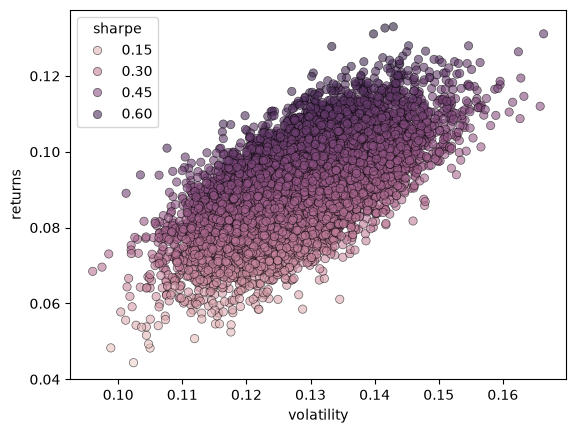

In [439]:
sns.scatterplot(x = 'volatility', y = 'returns', hue = 'sharpe', color='gold', edgecolors='black', alpha = 0.6, data = plot_df)

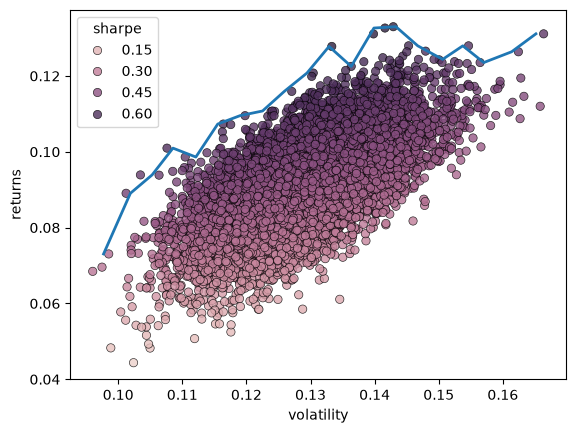

In [440]:
frontier = (
    plot_df
    .assign(vol_bin=pd.cut(plot_df["volatility"], bins=20))
    .groupby("vol_bin", observed=True)
    .agg({
        "volatility": "mean",
        "returns": "max"
    })
    .dropna()
)
sns.scatterplot(x = 'volatility', y = 'returns', hue = 'sharpe', color='gold', edgecolors='black', alpha = 0.8, data = plot_df)
plt.plot(frontier["volatility"], frontier["returns"], linewidth=2)

In [441]:
model_results.to_csv("data/processed/model_results.csv")